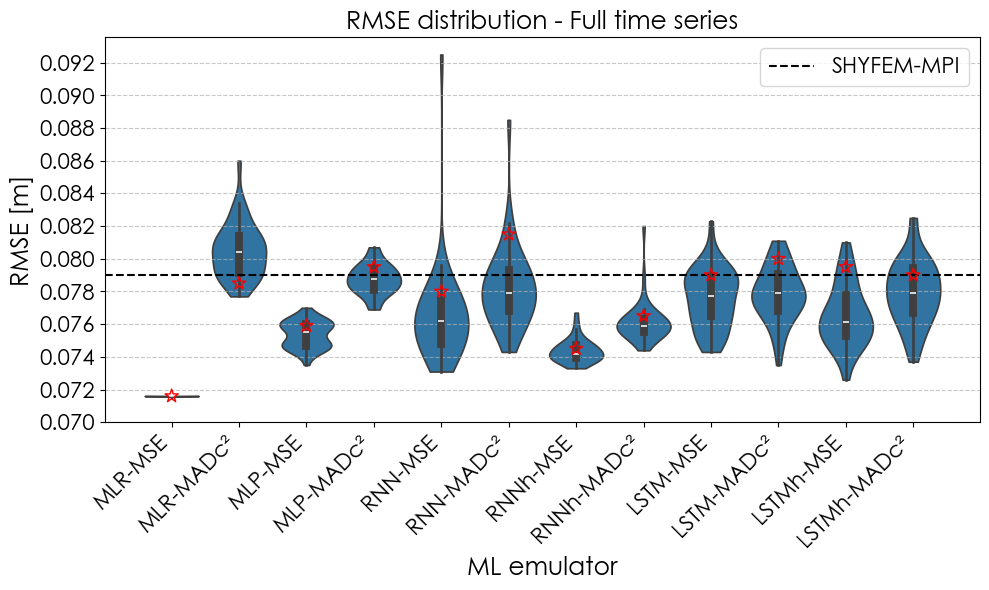

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Load Excel file
excel_path = 'Average_Error_Metrics_All_Emulators.xlsx'
xls = pd.ExcelFile(excel_path)

# Choose the metric to plot
metric_to_plot = 'RMSE'  # Change this as needed

# Initialize a list to collect DataFrames
df_list = []

# Loop through each sheet
for sheet_name in xls.sheet_names:
    # Read data and clean column names
    df = pd.read_excel(xls, sheet_name=sheet_name, skiprows=0)
    df.columns = df.columns.str.strip()  # Remove leading/trailing spaces

    if metric_to_plot not in df.columns:
        raise ValueError(f"Metric '{metric_to_plot}' not found in sheet '{sheet_name}'. Available columns: {df.columns.tolist()}")

    # Store the metric and sheet name
    df_metric = pd.DataFrame({
        'Sheet': sheet_name,
        'Value': df[metric_to_plot]
    })
    df_list.append(df_metric)

# Set the font family globally
mpl.rcParams['font.family'] = 'Century Gothic'

# Combine and rename
all_data = pd.concat(df_list, ignore_index=True)
all_data.columns = all_data.columns.str.strip()
# Rename to match plotting code
all_data = all_data.rename(columns={'Sheet': 'ML model', 'Value': 'RMSE [m]'})

# Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=all_data, x='ML model', y='RMSE [m]', inner='box', density_norm='width', cut=0)

# Control axis label font sizes
plt.xlabel('ML emulator', fontsize=18)       # x-axis label
plt.ylabel('RMSE [m]', fontsize=18)       # y-axis label
plt.title("RMSE distribution - Full time series", fontsize=18)

# Customize x-axis labels
custom_legend_labels = [
    'MLR-MSE', 'MLR-MADc²', 'MLP-MSE', 'MLP-MADc²', 'RNN-MSE', 'RNN-MADc²',
    'RNNh-MSE', 'RNNh-MADc²', 'LSTM-MSE', 'LSTM-MADc²', 'LSTMh-MSE', 'LSTMh-MADc²'
]
plt.xticks(ticks=np.arange(len(custom_legend_labels)), labels=custom_legend_labels, rotation=45, ha='right', fontsize=16)

# Reference line for BC-UniGe
# For MADc:
#bcunige = 0.066
# For MADp
#bcunige = 0.006
# For RMSE:
bcunige = 0.079

plt.axhline(y=bcunige, color='black', linestyle='--', linewidth=1.5, label='SHYFEM-MPI')

# Best performance vector
# For MADc:
#values_vector = [0.0700,	0.0685,	0.0688,	0.0675,	0.0695,	0.0760,	0.0645,	0.0670,	0.0710,	0.0705,	0.0700,	0.0695]
# For MADp:
#values_vector = [0.0144,	0.0075,	0.010,	0.006,	0.009,	0.0122,	0.007,	0.009,	0.009,	0.007,	0.009,	0.007]
# For RMSE:
values_vector = [0.0716,	0.0785,	0.0759,	0.0795,	0.0780,	0.0815,	0.0745,	0.0765,	0.0790,	0.0800,	0.0795,	0.0790]

# Plot the stars on top of the violins without fill
for i, value in enumerate(values_vector):
    plt.scatter(i, value, color='red', marker='*', s=100, edgecolor='red', facecolors='none', zorder=3)

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set the y-axis ticks every 0.001
# For MADc:
#y_min = 0.06
#y_max = 0.09
#y_ticks = np.arange(np.floor(y_min * 1000) / 1000, np.ceil(y_max * 1000) / 1000, 0.002)  
# For MADp
#y_min = 0.002
#y_max = 0.02
#y_ticks = np.arange(np.floor(y_min * 1000) / 1000, np.ceil(y_max * 1000) / 1000, 0.001)  
# For RMSE
y_min = 0.070
y_max = 0.094
y_ticks = np.arange(np.floor(y_min * 1000) / 1000, np.ceil(y_max * 1000) / 1000, 0.002)  

plt.yticks(y_ticks, fontsize=16)

# Add legend
plt.legend(loc='upper right', fontsize=16, frameon=True)

plt.tight_layout()

#plt.show()

# Save the figure
# For MADc:
#plt.savefig('violinplot_MADc_AllData', dpi=300, bbox_inches='tight')
# For MADp:
#plt.savefig('violinplot_MADp_AllData', dpi=300, bbox_inches='tight')
# For RMSE:
plt.savefig('violinplot_RMSE_AllData', dpi=300, bbox_inches='tight')